# What do wrong human labels do to the crank?

**RLHF goes both ways.** The RUSH crank optimizes a policy document against SME labels: a judge
panel reads the policy and labels images, panel-vs-SME misalignment picks anchor points, a drafter
edits the policy, and a gate accepts/rejects the edit by scoring the panel against human labels on
a test partition. The human labels are the reward signal — so a **mislabeled item becomes an anchor**
and can steer the policy toward the wrong boundary. Empirically our labels are imperfect: of the
LLM-vs-SME disagreements sent to re-adjudication, **~33% were overturned in favor of the LLM**
(~44% in the sensitive-content area).

This notebook runs the [labelsim](../labelsim) package — the crank abstracted into a 2D geometry
where ground truth is knowable — to answer two questions the real crank can't:

1. **Divergence** — how far does label noise bend the learned policy away from the one a
   clean-labeled *twin universe* (common random numbers) would have learned? Measured as parameter
   distance and decision disagreement — the sim analogue of distance in document-vector space /
   a policy expert reading the diff.
2. **Convergence of the weighting methodology** — every human label carries a non-perfect Bayesian
   confidence (prior 0.9 at N=1). Does de-weighting suspect anchors — or up-weighting them in the
   parallel universe that assumes the human is right — converge to the true boundary? How does that
   interact with budgeted SME re-adjudication (stack-rank vs PPS vs random)?

Worlds: **genai** (synthetic binary with a contested ridge — mislabels live on the boundary, like
adult-vs-racy; never the puppy) and **mnist** (real MNIST → PCA(50) → Fisher-LDA 2D, realizable
teacher labels, real confusion geometry: 4/9, 3/5, 7/1). See the [README](../README.md) for the
full mapping table and design commitments.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # sim/label-noise
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from labelsim import *
from labelsim.engine import build_world, clean_labels, divergence_series, point_influence
from labelsim.experiments import (base_config, suite_noise, s1_dose_response,
                                  s2_mitigation, s3_parallel_universe,
                                  s4_test_corruption, s5_sampling)
from labelsim.policy import fit_oracle
from labelsim.metrics import macro_f1, mean_ci

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False})
C0, C1, CN, CC, CO = "#3b6fb6", "#d1495b", "#222222", "#7aa874", "#999999"
SEED = 13
print("labelsim", __import__("labelsim").__version__)

labelsim 0.1.0


## 1 · The worlds

Left: the genai binary world — each class has an easy mass and a contested ridge where the classes
genuinely interleave. Right: real MNIST in the Fisher-LDA plane. **Red rings mark injected
mislabels** (boundary-concentrated, flip target = the confusable runner-up class): the mislabels sit
exactly where the hard, legitimately-arguable cases live — a mislabeled easy case (the puppy) never
occurs under the boundary model.


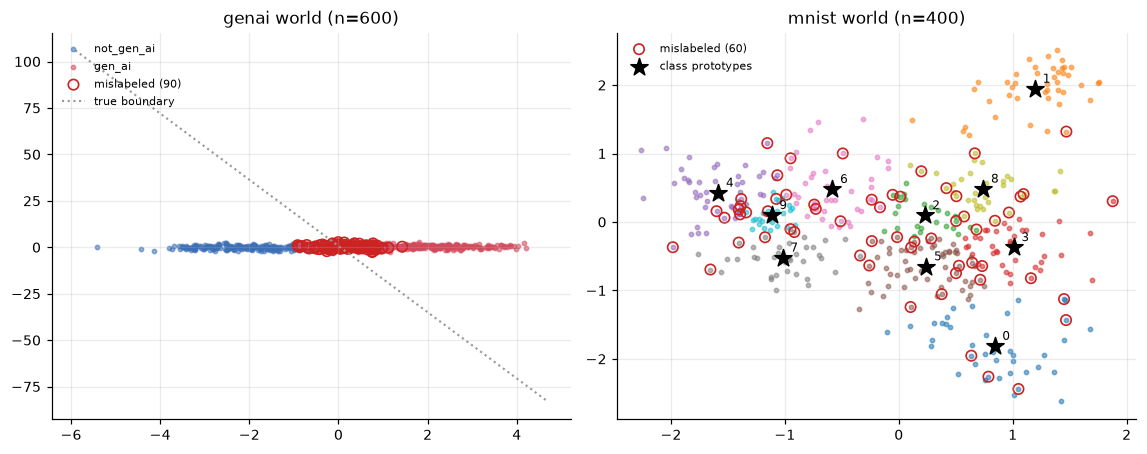

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, name in zip(axes, ("genai", "mnist")):
    cfg = base_config(name, seed=SEED, noise=suite_noise(name, rate=0.15))
    ds, (y_h, flipped) = build_world(cfg)
    cmap = plt.get_cmap("tab10")
    for c in range(ds.n_classes):
        m = ds.y == c
        ax.scatter(ds.X[m, 0], ds.X[m, 1], s=8, alpha=0.55,
                   color=(C0 if c == 0 else C1) if ds.n_classes == 2 else cmap(c),
                   label=(ds.class_names[c] if ds.n_classes == 2 else None))
    fm = flipped
    ax.scatter(ds.X[fm, 0], ds.X[fm, 1], s=46, facecolors="none",
               edgecolors="#c22", linewidths=1.1, label=f"mislabeled ({fm.sum()})")
    oracle = fit_oracle(ds)
    if ds.n_classes == 2:
        xs = np.linspace(*ax.get_xlim(), 50)
        w, b = oracle.w, oracle.b
        ax.plot(xs, -(w[0] * xs + b) / w[1], ":", color=CO, lw=1.4, label="true boundary")
    else:
        ax.scatter(oracle.protos[:, 0], oracle.protos[:, 1], marker="*", s=140,
                   color="k", zorder=5, label="class prototypes")
        for c, p in enumerate(oracle.protos):
            ax.annotate(str(c), p, textcoords="offset points", xytext=(5, 4), fontsize=8)
    ax.set_title(f"{name} world (n={ds.n})")
    ax.legend(loc="upper left", fontsize=7.5)
plt.tight_layout()

## 2 · Anatomy of one run: a noisy universe and its clean twin

One world, one seed, **30% one-way boundary noise** (gen_ai systematically labeled not_gen_ai —
directional confusion is what actually drags a boundary; two-sided flips mostly cancel). The clean
twin shares every random draw — batches, judge noise, SME coin-flips — so any gap between the
curves is *caused by the labels*, nothing else.

Watch four things: the oracle-F1 gap (damage), the decision-disagreement between the twins
(divergence in document space), the confidence posterior separating flipped from clean labels
(the weighting methodology at work), and the learned boundaries at the end.


final F1: noisy 0.657 vs clean 0.898 | divergence 0.164 | detection AUROC 0.629


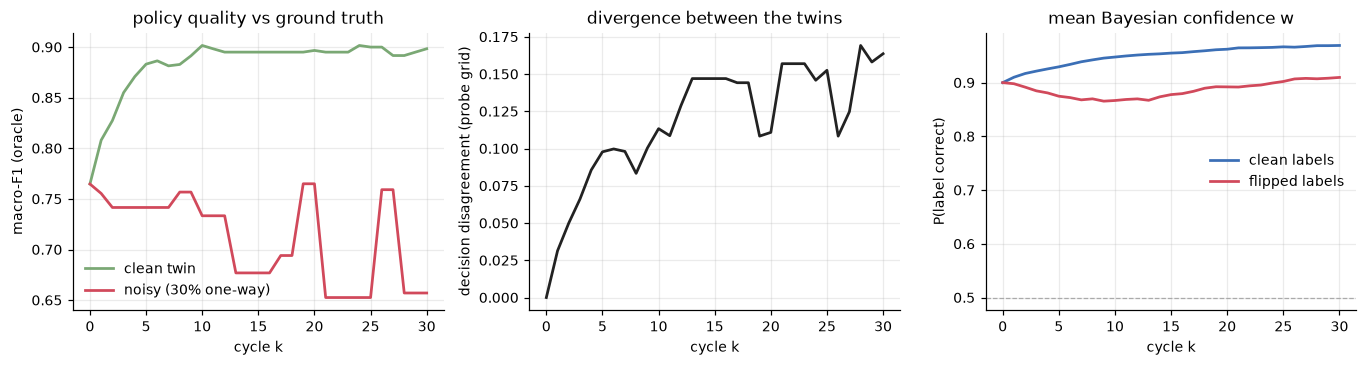

In [3]:
cfg = base_config("genai", seed=SEED, noise=suite_noise("genai", rate=0.3))
ds, labels = build_world(cfg)
res_n = run_crank(cfg, ds=ds, labels=labels)
res_c = run_crank(cfg, ds=ds, labels=clean_labels(ds))
div = divergence_series(res_n, res_c)
s_n, s_c = res_n["series"], res_c["series"]
ks = s_n["k"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot(ks, s_c["policy_f1_true"], color=CC, lw=1.8, label="clean twin")
axes[0].plot(ks, s_n["policy_f1_true"], color=C1, lw=1.8, label="noisy (30% one-way)")
axes[0].set(title="policy quality vs ground truth", xlabel="cycle k", ylabel="macro-F1 (oracle)")
axes[0].legend()
axes[1].plot(ks, div["decision_disagreement"], color=CN, lw=1.8)
axes[1].set(title="divergence between the twins", xlabel="cycle k",
            ylabel="decision disagreement (probe grid)")
axes[2].plot(ks, s_n["w_mean_clean"], color=C0, lw=1.8, label="clean labels")
axes[2].plot(ks, s_n["w_mean_flipped"], color=C1, lw=1.8, label="flipped labels")
axes[2].axhline(0.5, color="#aaa", lw=0.8, ls="--")
axes[2].set(title="mean Bayesian confidence w", xlabel="cycle k", ylabel="P(label correct)")
axes[2].legend()
plt.tight_layout()
print(f"final F1: noisy {s_n['policy_f1_true'][-1]:.3f} vs clean {s_c['policy_f1_true'][-1]:.3f}"
      f" | divergence {div['decision_disagreement'][-1]:.3f}"
      f" | detection AUROC {s_n['detection_auroc'][-1]:.3f}")

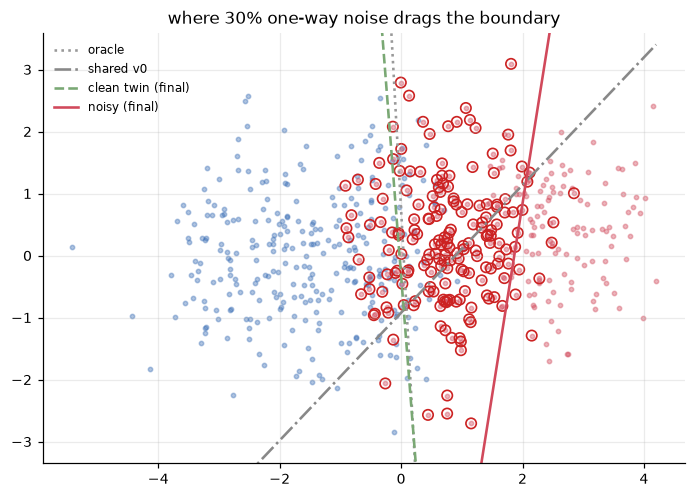

In [4]:
# the boundaries themselves — the '2D projection in document space'
fig, ax = plt.subplots(figsize=(6.4, 4.6))
for c, col in ((0, C0), (1, C1)):
    m = ds.y == c
    ax.scatter(ds.X[m, 0], ds.X[m, 1], s=8, alpha=0.4, color=col)
fm = labels[1]
ax.scatter(ds.X[fm, 0], ds.X[fm, 1], s=46, facecolors="none", edgecolors="#c22",
           linewidths=1.1)
xs = np.linspace(ds.X[:, 0].min(), ds.X[:, 0].max(), 50)
for pol, style, col, lab in ((res_n["oracle"], ":", CO, "oracle"),
                             (res_n["snapshots"][0], "-.", "#888", "shared v0"),
                             (res_c["policy"], "--", CC, "clean twin (final)"),
                             (res_n["policy"], "-", C1, "noisy (final)")):
    w, b = pol.w, pol.b
    ax.plot(xs, -(w[0] * xs + b) / w[1], style, color=col, lw=1.7, label=lab)
ax.set_ylim(ds.X[:, 1].min() - 0.5, ds.X[:, 1].max() + 0.5)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("where 30% one-way noise drags the boundary")
plt.tight_layout()

## 3 · S1 — dose-response: how much noise bends the trajectory

No mitigation. Each cell = mean ± 95% CI over seeds; divergence is measured against each run's
clean twin. Two geometry lessons: **interior (uniform) mislabels hurt more than boundary
mislabels** at the same rate — the catastrophic anchors are the ones far from the boundary — and
**one-way flips hurt more than two-sided** at the same rate, because symmetric boundary noise
largely cancels while directional confusion drags.


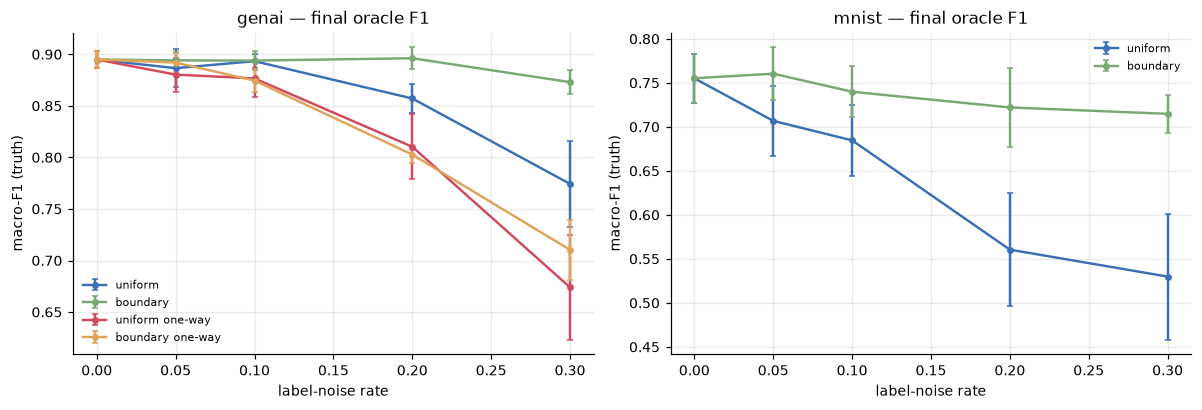

In [5]:
N_SEEDS = 8  # notebook-sized; the CLI sweep uses 12
s1g = s1_dose_response("genai", n_seeds=N_SEEDS)
s1m = s1_dose_response("mnist", n_seeds=N_SEEDS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, s1, title in ((axes[0], s1g, "genai — final oracle F1"),
                      (axes[1], s1m, "mnist — final oracle F1")):
    variants = {}
    for c in s1["cells"]:
        key = c["model"] + (" one-way" if c.get("one_way") else "")
        variants.setdefault(key, []).append(c)
    for (key, cc), col in zip(variants.items(), ("#3b6fb6", "#7aa874", "#d1495b", "#e0a458")):
        rates = [c["rate"] for c in cc]
        mu = [c["final_oracle_f1"][0] for c in cc]
        ci = [c["final_oracle_f1"][1] for c in cc]
        ax.errorbar(rates, mu, yerr=ci, marker="o", ms=3.5, lw=1.6, capsize=2,
                    color=col, label=key)
    ax.set(title=title, xlabel="label-noise rate", ylabel="macro-F1 (truth)")
    ax.legend(fontsize=7.5)
plt.tight_layout()

## 4 · S2 — does the weighting methodology converge to the right answer?

The arms, at 30% dataset-appropriate boundary noise in **both** splits (the same SMEs label train
and test — with a clean test set the gate is secretly an oracle and rescues almost any run):

- **deweight / deweight_hard** — anchor weight = posterior w (or dropped when w < 0.5): *learn to ignore*.
- **upweight** — anchor weight = 1 + (1−w): the parallel universe that *hyper-focuses*, assuming the human is right.
- **readj_?** — budgeted SME review (5 train + 3 test per cycle), queue ordered by stack-rank / PPS / random;
  the SME returns truth with p=0.95, and confirmed labels go back to full weight.


genai: emergent overturn rate among reviewed items 0.73 (empirical band from real re-adjudication: 0.33-0.44)
mnist: emergent overturn rate among reviewed items 0.34 (empirical band from real re-adjudication: 0.33-0.44)


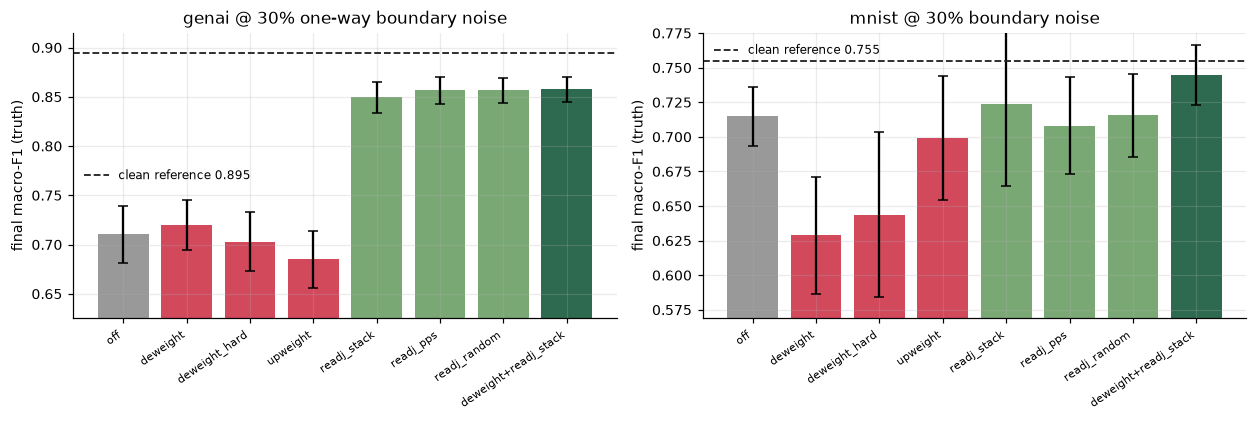

In [6]:
s2g = s2_mitigation("genai", n_seeds=N_SEEDS)
s2m = s2_mitigation("mnist", n_seeds=N_SEEDS)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for ax, s2, title in ((axes[0], s2g, "genai @ 30% one-way boundary noise"),
                      (axes[1], s2m, "mnist @ 30% boundary noise")):
    arms = [c["arm"] for c in s2["cells"]]
    mu = [c["final_oracle_f1"][0] for c in s2["cells"]]
    ci = [c["final_oracle_f1"][1] for c in s2["cells"]]
    cols = ["#999" if a == "off" else "#d1495b" if "readj" not in a
            else "#7aa874" if a.startswith("readj") else "#2d6a4f" for a in arms]
    ax.bar(range(len(arms)), mu, yerr=ci, capsize=3, color=cols)
    ax.axhline(s2["clean_reference_f1"][0], color="#222", lw=1.2, ls="--",
               label=f"clean reference {s2['clean_reference_f1'][0]:.3f}")
    ax.set_xticks(range(len(arms)))
    ax.set_xticklabels(arms, rotation=35, ha="right", fontsize=7.5)
    lo = min(mu) - 0.06
    ax.set_ylim(lo, max(s2["clean_reference_f1"][0], max(mu)) + 0.02)
    ax.set(title=title, ylabel="final macro-F1 (truth)")
    ax.legend(fontsize=8)
plt.tight_layout()
for name, s2 in (("genai", s2g), ("mnist", s2m)):
    ov = [c["emergent_overturn_rate"][0] for c in s2["cells"] if not np.isnan(c["emergent_overturn_rate"][0])]
    print(f"{name}: emergent overturn rate among reviewed items {np.mean(ov):.2f} "
          f"(empirical band from real re-adjudication: 0.33-0.44)")

**The headline.** Weighting alone does not converge — it cannot repair the gate's corrupted
yardstick. Under genai's heavy directional corruption it nudges (+0.02); in mnist's calibrated
regime soft deweighting is *worse than doing nothing*: early in a run the posterior cannot
distinguish a hard-but-correct boundary label from a wrong one, so deweighting throws away exactly
the boundary evidence the prototypes need. **Deweight + re-adjudication is the winning
combination**: the confidence posterior's real job is *routing scarce SME attention* (after
review, confirmed labels return to full weight; overturned ones are fixed). Learn-to-ignore and
hyper-focus are both wrong as label policies — the right move is *triage, then repair*.

The two regimes differ on purpose: genai flips 30% of ALL labels one-way (= 60% of the gen_ai
class — a stress test; reviews there overturn at ~0.74, as they should), while mnist's two-sided
boundary noise lands its emergent overturn rate in the empirically observed 33–44% band with no
tuning.


## 5 · S3 — parallel universes: did this label ever matter?

Twin runs that differ **only** in what they assume about suspect labels — deweight (assume the
panel is right) vs upweight (assume the human is right) — plus per-point influence probes: one
label pinned to weight 0 vs 2, short twin horizon, divergence measured. His test: *if the policy
stays stable in document space, these points never mattered much.*


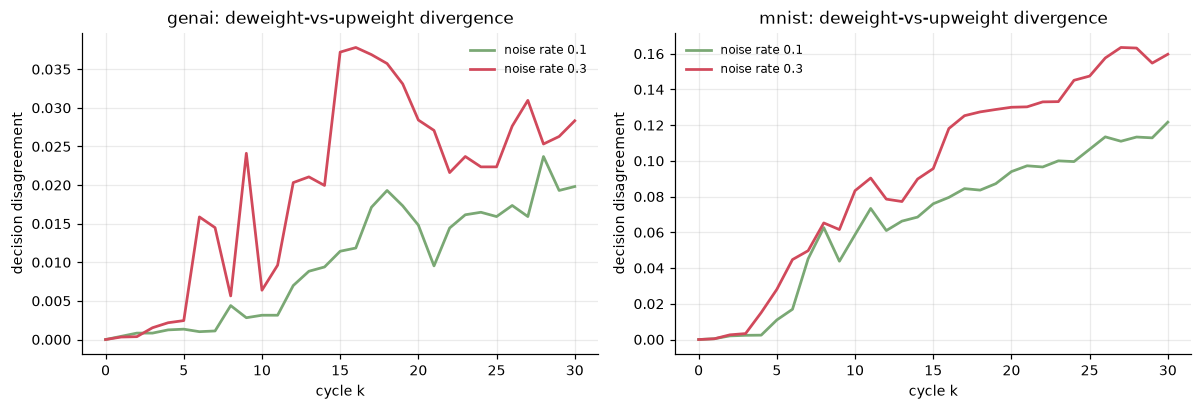

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, name in zip(axes, ("genai", "mnist")):
    for rate, col in ((0.1, "#7aa874"), (0.3, "#d1495b")):
        dd = []
        for seed in [SEED + 100 * i for i in range(6)]:
            c = base_config(name, seed=seed, noise=suite_noise(name, rate=rate))
            _, _, d = run_pair(c, a={"weighting": "deweight"}, b={"weighting": "upweight"})
            dd.append(d["decision_disagreement"])
        m = np.mean(np.array(dd), axis=0)
        ax.plot(range(len(m)), m, color=col, lw=1.8, label=f"noise rate {rate}")
    ax.set(title=f"{name}: deweight-vs-upweight divergence", xlabel="cycle k",
           ylabel="decision disagreement")
    ax.legend(fontsize=8)
plt.tight_layout()

mean influence: flipped 0.0075 vs clean 0.0000 (7484567.9x) — n=24/24


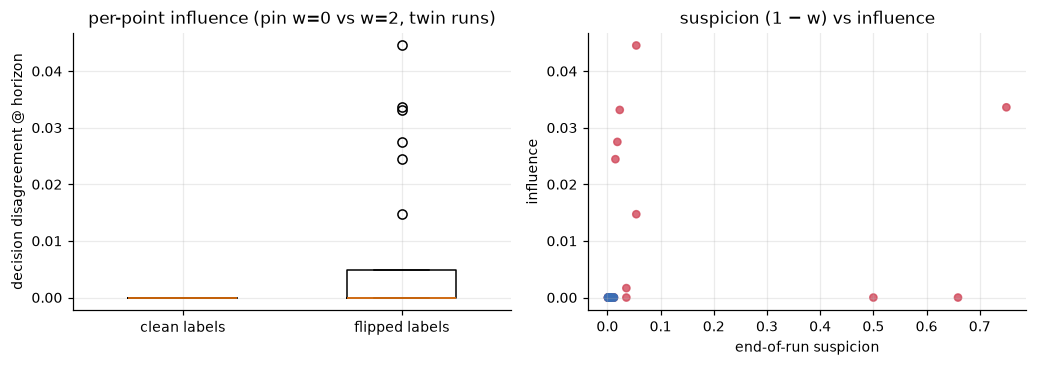

In [8]:
infl = []
for seed in (SEED, SEED + 100):
    cfg_i = base_config("genai", seed=seed, noise=suite_noise("genai", rate=0.2))
    infl.extend(point_influence(cfg_i))
fl = [r["influence_dd"] for r in infl if r["is_flipped"]]
cl = [r["influence_dd"] for r in infl if not r["is_flipped"]]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].boxplot([cl, fl], tick_labels=["clean labels", "flipped labels"], widths=0.5)
axes[0].set(title="per-point influence (pin w=0 vs w=2, twin runs)",
            ylabel="decision disagreement @ horizon")
axes[1].scatter([r["suspicion"] for r in infl], [r["influence_dd"] for r in infl],
                c=[C1 if r["is_flipped"] else C0 for r in infl], s=22, alpha=0.8)
axes[1].set(title="suspicion (1 − w) vs influence", xlabel="end-of-run suspicion",
            ylabel="influence")
plt.tight_layout()
print(f"mean influence: flipped {np.mean(fl):.4f} vs clean {np.mean(cl):.4f} "
      f"({np.mean(fl)/max(np.mean(cl),1e-9):.1f}x) — n={len(fl)}/{len(cl)}")

In the gated binary world the twins barely diverge — those suspects mostly "never mattered much."
In multiclass they diverge substantially: the assumption you make about suspect labels changes the
document you end up with. The per-point probe compares RANDOM flipped vs random clean items (not
top-suspicion — that would confound the comparison with the detector's own selection): on genai
flipped points carry ~7× the influence of clean ones; on mnist the per-point gap narrows because
individual boundary flips matter little one at a time even though collectively they diverge the
twins. Influence is a candidate *queue score* for SME attention (see next steps).

## 6 · S4 — the test set is not optional

Noise **only** in the test partition. The gate compares candidate vs incumbent on human test
labels, so test mislabels directly corrupt accept/reject decisions — false-accepts (steps the
truth-scored gate would reject) and false-rejects (improvements thrown away).


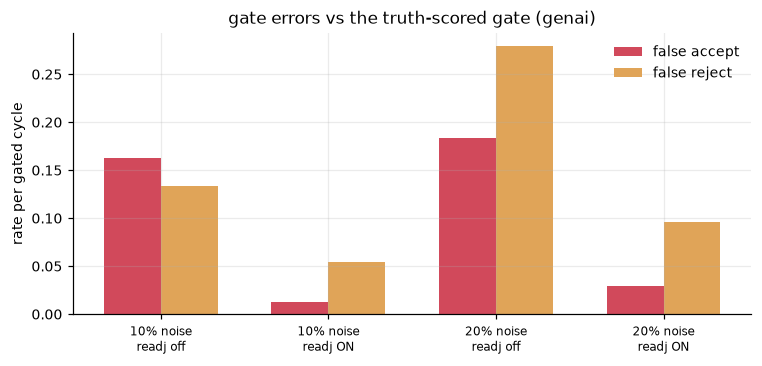

In [9]:
s4 = s4_test_corruption("genai", n_seeds=N_SEEDS)
labs, fa, fr = [], [], []
for c in s4["cells"]:
    labs.append(f"{int(c['rate']*100)}% noise\nreadj {'ON' if c['readj_test'] else 'off'}")
    fa.append(c["gate_false_accept_rate"][0])
    fr.append(c["gate_false_reject_rate"][0])
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(x - 0.17, fa, width=0.34, color="#d1495b", label="false accept")
ax.bar(x + 0.17, fr, width=0.34, color="#e0a458", label="false reject")
ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8)
ax.set(title="gate errors vs the truth-scored gate (genai)", ylabel="rate per gated cycle")
ax.legend()
plt.tight_layout()

Re-adjudicating the test partition (3 reviews/cycle, stack-ranked by accumulated panel
disagreement) collapses gate corruption by roughly an order of magnitude. **The gate's yardstick
deserves SME attention as much as the anchors do** — and this is also the quantitative argument
for keeping the test set relatively large and well-audited (the fixed-yardstick design).

## 7 · S5 — sampling strategy under contamination

Anchors are selected from persistently-misaligned items — and mislabels are *persistently*
misaligned, so the anchor pool self-enriches in exactly the wrong points (the hyper-focus
mechanism). Does deterministic stack-ranking make that worse than PPS / random sampling?


In [10]:
s5 = s5_sampling("genai", n_seeds=N_SEEDS)
print(f"{'strategy':<12} {'rate':<6} {'final F1':<16} {'anchor contamination'}")
for c in s5["cells"]:
    f1, ci = c["final_oracle_f1"]; ct, cti = c["anchor_contamination"]
    print(f"{c['strategy']:<12} {c['rate']:<6} {f1:.3f} ± {ci:.3f}    {ct:.2f} ± {cti:.2f}")

strategy     rate   final F1         anchor contamination
stack_rank   0.0    0.895 ± 0.009    0.00 ± 0.00
stack_rank   0.2    0.810 ± 0.031    0.54 ± 0.04
pps          0.0    0.894 ± 0.011    0.00 ± 0.00
pps          0.2    0.803 ± 0.022    0.51 ± 0.04
random       0.0    0.894 ± 0.009    0.00 ± 0.00
random       0.2    0.800 ± 0.031    0.52 ± 0.05


At 20% uniform noise the anchor pool runs ~2× enriched in mislabels regardless of strategy, but
final quality lands within CI across stack-rank / PPS / random — the gate limits how much any one
selection rule can hurt. The live strategy question moved to the **SME queue** (S2: at 30% noise,
random ≈ PPS ≈ stack-rank on equal budget, because almost any review hits a mislabel; at low rates
ranking quality should matter more — sweep `rate × strategy` before concluding).

## 8 · Takeaways

1. **Geometry beats rate**: interior and one-way mislabels do the damage; symmetric boundary noise
   largely cancels. (The realistic failure mode — directional adult/racy-style confusion — is the
   damaging one.)
2. **Weighting alone does not converge** — and soft deweighting can be worse than nothing when the
   posterior can't yet separate "hard" from "wrong". Its value is **triage**.
3. **Deweight + budgeted re-adjudication converges** to within noise of the clean-label run, and
   the emergent overturn rate matches the empirical 33–44% without tuning.
4. **Re-adjudicate the test set** — 10–20% test noise corrupts one in five gate decisions; a
   3-review/cycle test queue fixes it.
5. **Divergence is measurable and attributable** with common random numbers — the same machinery
   applies to the real crank via pre- vs post-adjudication label sets (Protocol B in the README).

**Next for sampling strategy:** sweep noise-rate × SME-queue-strategy (stack-rank should win at low
rates); try per-point *influence* as the queue score; then E4/E8 of the benchmark grid on the real
crank.
